# CNN Demo: Classification of cells

A CNN is used to distinguish between healthy and Malaria infected cells using the Malaria Cell Images Dataset (from kaggle: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria)

The training takes quite a while, so this notebook is intended for demo only. The dataset has been removed from the repo to save space (around 700 MB). If you are interested how load datasets from kaggle, have a look at the `kaggle-dl.ipynb` notebook.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


Prepare dataset (downsize images)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(), #64x64 RGB image becomes 3x64x64 tensor, also normalizes pixel values (from 0-255 to 0-1)
    transforms.Normalize([0.5, 0.5, 0.5], # set normalisation mean; normalises each colour channel
                         [0.5, 0.5, 0.5]) # set std dev; from [0, 1] to [-1, 1] range 
                         # makes training more stable, converge faster
])

dataset = datasets.ImageFolder(
    root="cell_images",
    transform=transform
)

Train-test split (using pytorch functionality)

In [ ]:
from torch.utils.data import random_split

train_size = int(0.6 * len(dataset)) # large test size chosen for quicker training
test_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, test_size]
)

Wrap dataset into loaders

In [ ]:
train_loader = DataLoader(train_dataset,
                          batch_size=128,
                          shuffle=True)

test_loader = DataLoader(val_dataset,
                        batch_size=128,
                        shuffle=False)

Quick inspection of data batches

In [ ]:
images, labels = next(iter(train_loader)) # create an iterator, next simply calls the first batch

print(images.shape)
print(labels.shape)

torch.Size([128, 3, 64, 64])
torch.Size([128])


Building the CNN:

In [ ]:
class CellCNN(nn.Module):
    def __init__(self):
        super(CellCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # 64x64
            nn.ReLU(),
            nn.MaxPool2d(2),                 # 32x32

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # 16x16

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)                  # 8x8
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

Alternative (and more usual) way to define the model class - here however, less intuitive!

In [ ]:
# alternative and more usual class definition (clear separation of layers and forward pass!)
import torch.nn.functional as F

class CellCNN(nn.Module):
    def __init__(self):
        super(CellCNN, self).__init__()

        # 3 input channel, 16 output channels, 3×3 kernel
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)

        # 16 input channels to 32 output channels
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        # 32 input channels to 64 output channels
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)


        # fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128)  # after 3 poolings, 64x64 to 8x8
        self.fc2 = nn.Linear(128, 10)          # 10 classes for MNIST

    def forward(self, x):
        x = F.relu(self.conv1(x))      # -> (B,16,64,64)
        x = F.max_pool2d(x, 2)         # -> (B,16,32,32)

        x = F.relu(self.conv2(x))      # -> (B,32,32,32)
        x = F.max_pool2d(x, 2)         # -> (B,32,16,16)

        x = F.relu(self.conv3(x))      # -> (B,64,16,16)
        x = F.max_pool2d(x, 2)         # -> (B,64,8,8)

        x = x.view(x.size(0), -1)      # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Initialise model, set loss function and optimizer.

In [19]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CellCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Define training and evaluation functions

In [ ]:
def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

Train the model

In [ ]:
epochs = 10

for epoch in range(epochs):
    train_loss = train(model, train_loader)
    val_acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, Val Acc={val_acc:.4f}")

Epoch 1: Loss=0.5025, Val Acc=0.9267
Epoch 2: Loss=0.1622, Val Acc=0.9547
Epoch 3: Loss=0.1327, Val Acc=0.9520
Epoch 4: Loss=0.1287, Val Acc=0.9556
Epoch 5: Loss=0.1217, Val Acc=0.9567
Epoch 6: Loss=0.1178, Val Acc=0.9585
Epoch 7: Loss=0.1092, Val Acc=0.9568
Epoch 8: Loss=0.1045, Val Acc=0.9572
Epoch 9: Loss=0.1005, Val Acc=0.9573
Epoch 10: Loss=0.0918, Val Acc=0.9575


Visualise some predictions.

In [ ]:
def show_predictions(model, loader):
    model.eval()

    # load a batch
    images, labels = next(iter(loader))

    # predict labels for the batch
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    images = images.cpu()

    # create a subplot of first entries of the batch
    fig, axes = plt.subplots(1, 6, figsize=(12, 3)) #show first 6 images of the batch
    for i, ax in enumerate(axes):
        img = images[i].permute(1, 2, 0)
        ax.imshow(img)
        ax.set_title(f"Pred: {preds[i].item()}")
        ax.axis("off")

    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7647059].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.73333335].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6313726].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.56078434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7019608].


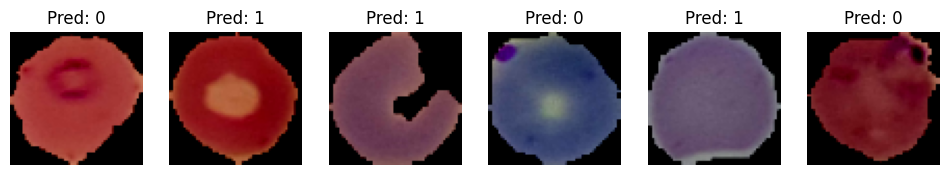

In [ ]:
show_predictions(model, test_loader)